## Debug confetti gradient maps from average connectivity

17.10.2025

- 1. GM fitting on individual CMs

In [ ]:
import numpy as np
import os.path as op

bids_folder = '/mnt_01/ds-asd' # /mnt_01/ds-dnumrisk
task = 'chase'

In [ ]:
sub = '01'
cm_sub_fn = op.join(bids_folder, 'derivatives', 'correlation_matrices',f'sub-{sub}_ses-1_task-{task}_space-fsaverage5_confspec-36P_CM.npy')

cm  = np.load(cm_sub_fn)
print(cm.shape)

(20484, 20484)


In [ ]:
from nilearn import datasets

def get_basic_mask():
    atlas = datasets.fetch_atlas_surf_destrieux()
    regions = atlas['labels'].copy()
    masked_regions = ['Medial_wall', 'Unknown']
    masked_labels = [regions.index(r) for r in masked_regions]
    for r in masked_regions:
        regions.remove(r)
    labeling = np.concatenate([atlas['map_left'], atlas['map_right']])
    labeling_noParcel = np.arange(0,len(labeling),1,dtype = int)     # Map gradients to original parcels
    mask = ~np.isin(labeling, masked_labels)
    return mask, labeling_noParcel

In [ ]:
# this has been missing!!!  -- but should rather be done before CM calculation - on the timeseries level
mask, labeling_noParcel = get_basic_mask()

cm_filtered = cm[np.ix_(mask, mask)]

In [13]:
from brainspace.gradient import GradientMaps

n_components = 3
gm = GradientMaps(n_components=n_components) # , alignment='procrustes'
gm.fit(cm_filtered) 

,n_components,3
,approach,'dm'
,kernel,'normalized_angle'
,alignment,None
,random_state,None


In [14]:
from brainspace.utils.parcellation import map_to_labels

mask, labeling_noParcel = get_basic_mask()

gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/tmp/ipykernel_308092/2709098733.py:4: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_308092/2709098733.py:4: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


In [15]:
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage

def plot_grads(grad):
    fsaverage = fetch_surf_fsaverage() # default 5
    side_view = 'medial'
    cmap = 'jet'
    n_comp = 3

    figure, axes = plt.subplots(nrows=1, ncols=n_comp,figsize = (15,4), subplot_kw=dict(projection='3d'))
    for i in range(0,n_comp):
        gm = np.split(grad[i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
        gm_r = gm[1]
        nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                    view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                    bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[i]) #
        axes[i].set(title=f'grad {i+1}')
    #figure.suptitle(f'sub-{sub} {spec} {confspec}', y=0.9)

/tmp/ipykernel_308092/3100762361.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right


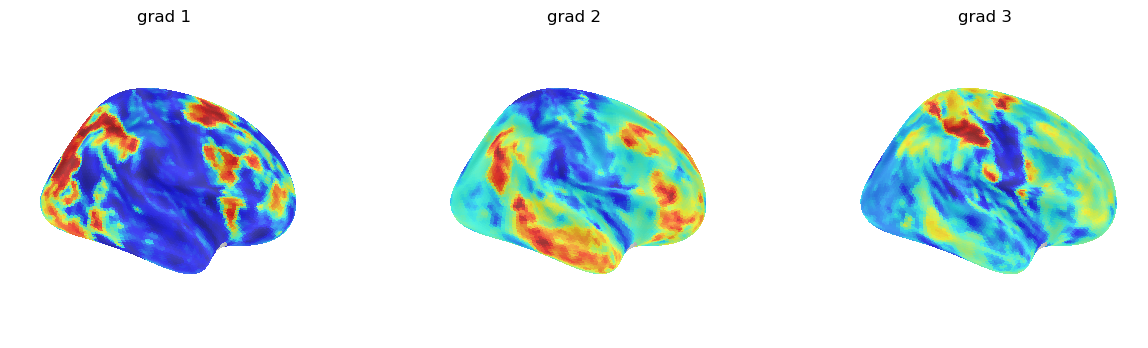

In [16]:
plot_grads(grad)